**CSV Analyser**

In [ ]:
#Mini Project which include descriptive stats and visualization

In [1]:
#import files which we use
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
#now import dataset which we want to use
path = "/content/OldCarsDataset.csv"
df = pd.read_csv(path)
df.head()

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,320
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,Sprinter 212
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,S 500
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,Q7
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,Rav 4


In [4]:
#basic dataset info
df.shape

(4345, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4345 entries, 0 to 4344
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         4345 non-null   object 
 1   Price         4173 non-null   float64
 2   Body          4345 non-null   object 
 3   Mileage       4345 non-null   int64  
 4   EngineV       4195 non-null   float64
 5   Engine Type   4345 non-null   object 
 6   Registration  4345 non-null   object 
 7   Year          4345 non-null   int64  
 8   Model         4345 non-null   object 
dtypes: float64(2), int64(2), object(5)
memory usage: 305.6+ KB


In [6]:
df.columns

Index(['Brand', 'Price', 'Body', 'Mileage', 'EngineV', 'Engine Type',
       'Registration', 'Year', 'Model'],
      dtype='object')

In [7]:
#checking missing values in dataset
df.isnull().sum()

,0
Brand,0
Price,172
Body,0
Mileage,0
EngineV,150
Engine Type,0
Registration,0
Year,0
Model,0


In [8]:
#data cleamning
df["Price"].fillna(df["Price"].median(), inplace= True)
df["EngineV"].fillna(df["EngineV"].median(), inplace = True)

#remove duplicate values
df.drop_duplicates(inplace=True)

df.isnull().sum()

,0
Brand,0
Price,0
Body,0
Mileage,0
EngineV,0
Engine Type,0
Registration,0
Year,0
Model,0


In [9]:
#descriptive stats
df.describe()

,Price,Mileage,EngineV,Year
count,4272.000000,4272.000000,4272.00000,4272.000000
mean,18680.058979,163.207631,2.76614,2006.419944
std,24364.870212,105.160123,5.01962,6.694256
min,600.000000,0.000000,0.60000,1969.000000
25%,7000.000000,90.000000,1.90000,2003.000000
50%,11500.000000,157.000000,2.20000,2008.000000
75%,20625.000000,230.000000,3.00000,2012.000000
max,300000.000000,980.000000,99.99000,2016.000000


In [10]:
#categorial Descriptive stats
df.describe(include=object)

,Brand,Body,Engine Type,Registration,Model
count,4272,4272,4272,4272,4272
unique,7,6,4,2,312
top,Volkswagen,sedan,Diesel,yes,E-Class
freq,927,1629,1969,3874,192


In [11]:
#final clean dataset after cleaning
df_clean = df.copy()
df.head(10)

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,320
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,Sprinter 212
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,S 500
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,Q7
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,Rav 4
5,Mercedes-Benz,199999.0,crossover,0,5.5,Petrol,yes,2016,GLS 63
6,BMW,6100.0,sedan,438,2.0,Gas,yes,1997,320
7,Audi,14200.0,vagon,200,2.7,Diesel,yes,2006,A6
8,Renault,10799.0,vagon,193,1.5,Diesel,yes,2012,Megane
9,Volkswagen,1400.0,other,212,1.8,Gas,no,1999,Golf IV


In [12]:
#visualiuzation of dataset for better understanding

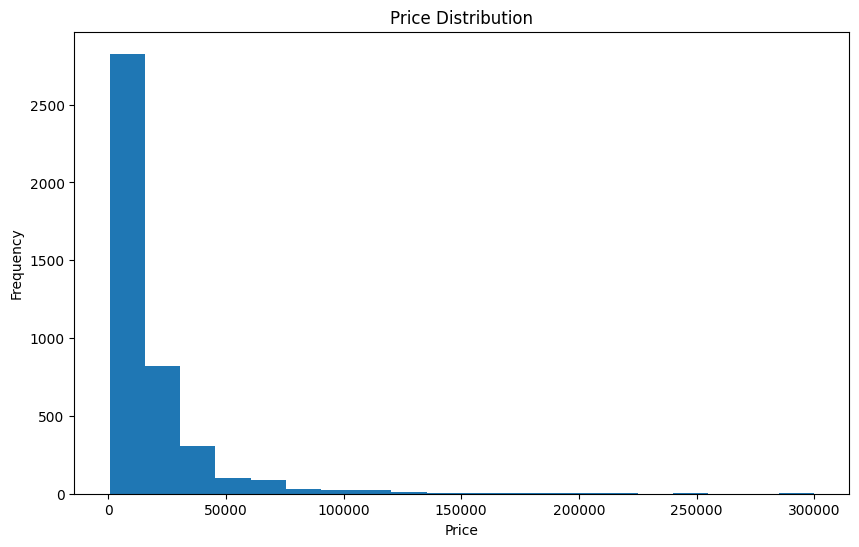

In [13]:
#price destribution
plt.figure(figsize=(10,6))
plt.hist(df_clean["Price"], bins=20)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Price Distribution")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

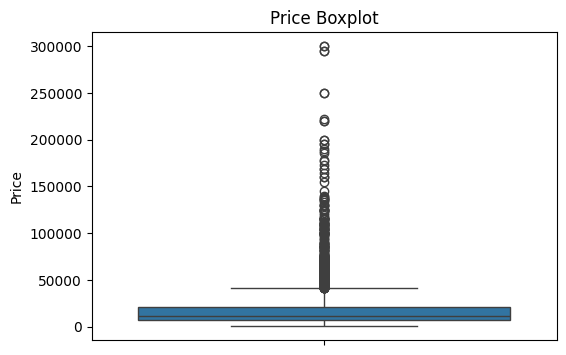

In [15]:
#Price Boxplot (outliers)
plt.figure(figsize=(6, 4))
sns.boxplot(df_clean["Price"])
plt.title("Price Boxplot")
plt.show

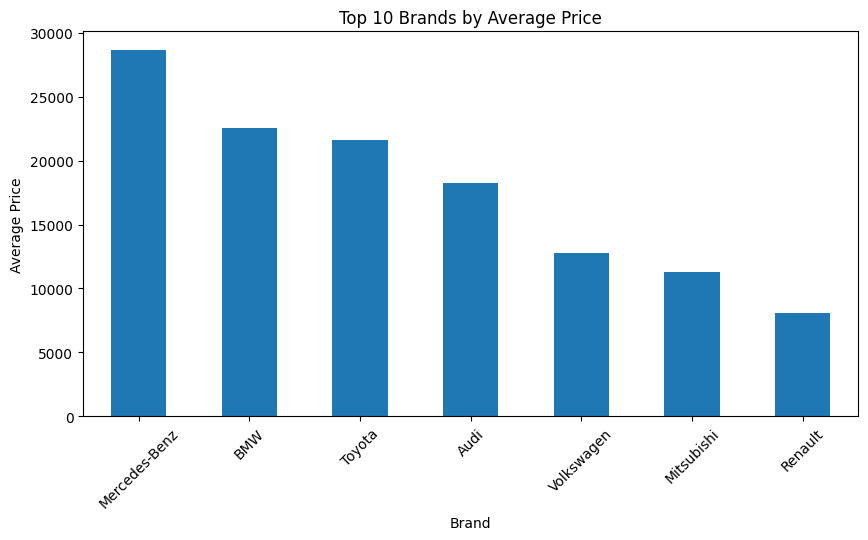

In [16]:
#average price by brand (Top 10)
top_brands = df_clean.groupby("Brand")["Price"].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
top_brands.plot(kind="bar")
plt.ylabel("Average Price")
plt.title("Top 10 Brands by Average Price")
plt.xticks(rotation=45)
plt.show()

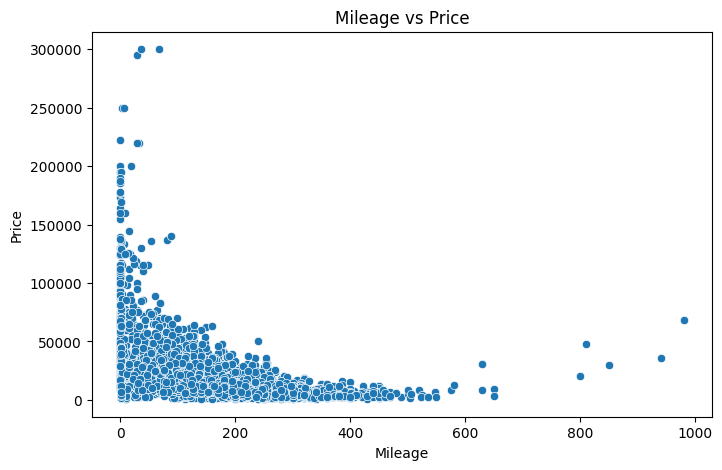

In [17]:
#Mileage vs Price
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_clean, x="Mileage", y="Price")
plt.title("Mileage vs Price")
plt.show()

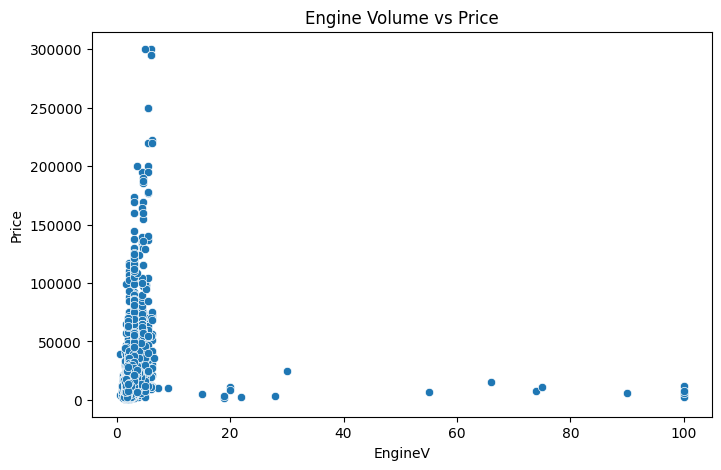

In [18]:
#Engine Volume vs Price
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_clean, x="EngineV", y="Price")
plt.title("Engine Volume vs Price")
plt.show()

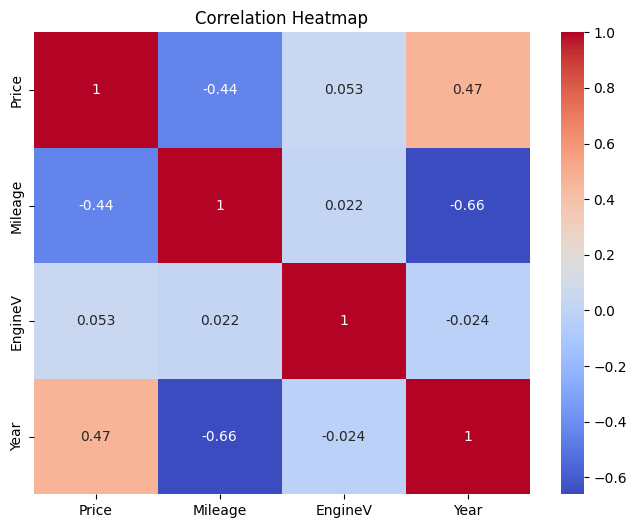

In [20]:
#Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    df_clean[["Price", "Mileage", "EngineV", "Year"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

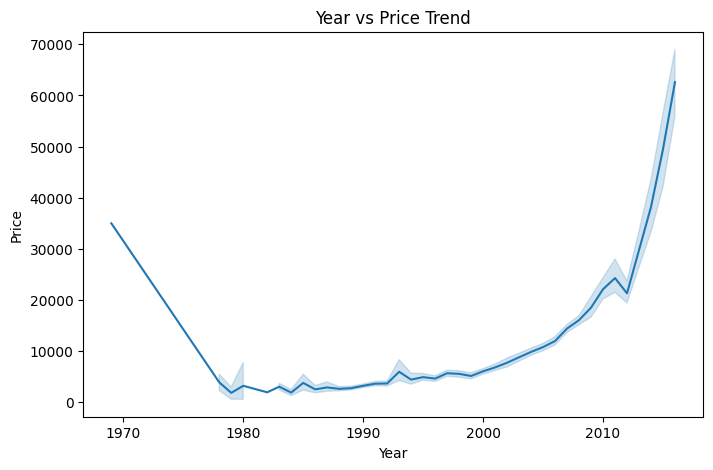

In [21]:
#Year vs Price
plt.figure(figsize=(8,5))
sns.lineplot(data=df_clean, x="Year", y="Price")
plt.title("Year vs Price Trend")
plt.show()